# Define a custom kernel

<a id="custom-metropolis-hastings-kernel"></a>

In [1]:
from collections.abc import Sequence
from dataclasses import dataclass

import jax
import jax.flatten_util
import jax.numpy as jnp
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel.goose as gs
import liesel.model as lsl
from liesel.goose import da  # dual averaging functionality
from liesel.goose.da import DualAvgState
from liesel.goose.pytree import (
    register_dataclass_as_pytree,  # dataclasses must be registered as pytrees with jax
)

## Supply an MH proposal

Start with {class}`~liesel.goose.MHKernel` when only your proposal is custom.
It handles acceptance/rejection and optional step size adaptation. A complete
kernel class is useful when you also need specialized state or tuning.

This runnable example estimates a normal mean. A symmetric random-walk proposal
is deliberately simple; for ordinary use, {class}`~liesel.goose.RWKernel` already
provides this update.

In [2]:
mu = lsl.Var.new_param(
    0.0,
    dist=lsl.Dist(tfd.Normal, 0.0, 2.0),
    name="mu",
)
y = lsl.Var.new_obs(
    jnp.array([0.8, 1.3, 0.9, 1.6, 1.1]),
    dist=lsl.Dist(tfd.Normal, mu, 1.0),
    name="y",
)
model = lsl.Model(y)

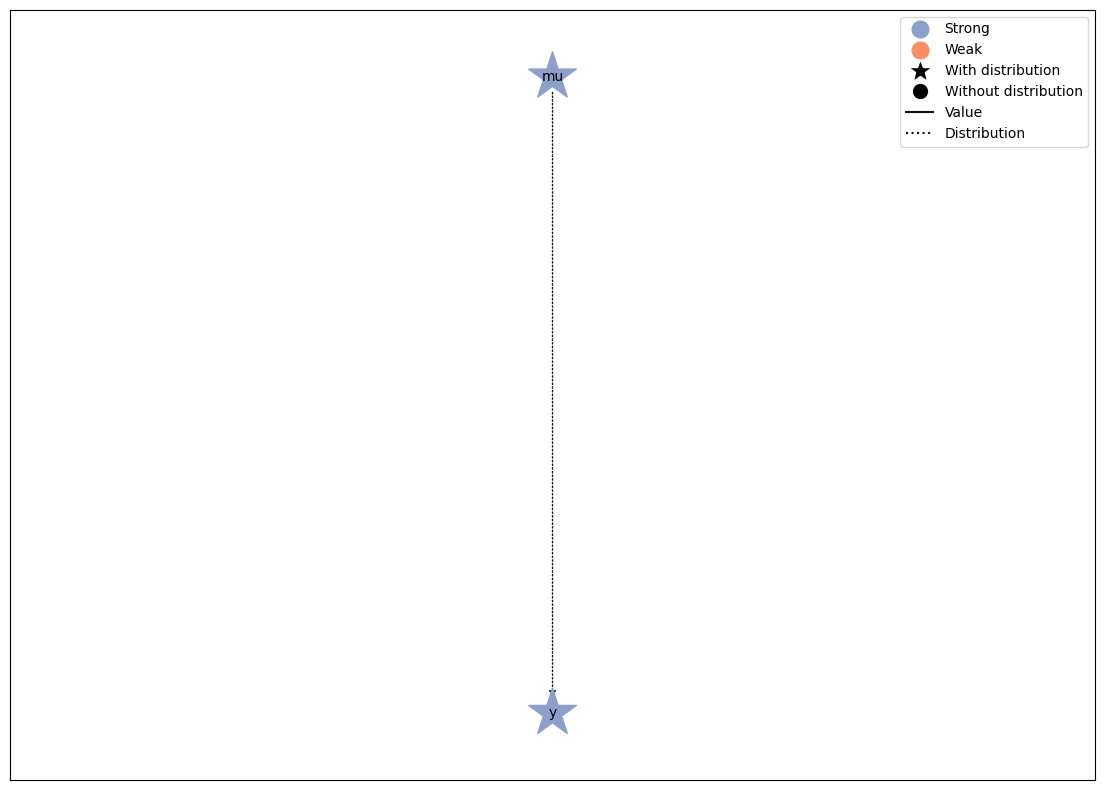

In [3]:
model.plot()

Define the proposal and attach it to the mean parameter:

In [4]:
def rw_proposal(prng_key, model_state, step_size):
    current = model.extract_position(["mu"], model_state)["mu"]
    proposed = current + step_size * jax.random.normal(prng_key, current.shape)
    return gs.MHProposal({"mu": proposed}, log_correction=0.0)


model.vars["mu"].inference = gs.MCMCSpec(
    gs.MHKernel,
    kernel_kwargs={"proposal_fn": rw_proposal, "da_tune_step_size": True},
    jitter_dist=tfd.Normal(0.0, 0.2),
)

In [5]:
results = gs.LieselMCMC(model).run_for_epochs(
    seed=7,
    num_chains=4,
    adaptation=1000,
    posterior=1000,
    show_progress=False,
)

liesel.goose.engine - INFO - Initializing kernels...


liesel.goose.engine - INFO - Done


liesel.goose.engine - INFO - Finished warmup


In [6]:
gs.Summary(results).to_dataframe()[["mean", "sd", "mcse_mean"]].round(3)

,mean,sd,mcse_mean
variable,,,
mu,1.076,0.41,0.018


The proposal function receives the random key, current model state, and step
size. It returns a {class}`~liesel.goose.MHProposal` containing a position and
the log proposal correction

$$
\log q(\text{current}\mid\text{proposed})
-\log q(\text{proposed}\mid\text{current}).
$$

For this symmetric normal proposal the correction is zero. For an asymmetric
proposal, compute it explicitly and sum over the proposed block's dimensions.
Use JAX-compatible calculations and the supplied key; do not change captured
model values or reuse a random key for independent draws.

In [7]:
gs.Summary(results).aggregate_diagnostics().round(3)

,ess_bulk,ess_tail,rhat,aggregated_by
parameter,,,,
mu,494.92,528.267,1.002,min (ess); max (rhat)


In [8]:
gs.Summary(results).error_df()

""


The estimated mean is about 1.08, with R-hat about 1.002 and bulk ESS about
495. The empty error table means no errors were recorded. Read these results
with the {doc}`diagnostics guide <../../goose-diagnostics>`.
For an exact full-conditional draw, use the
{doc}`Gibbs tutorial <01d-gibbs-sampling>` instead.

## Define a kernel state

Implement the {class}`~liesel.goose.Kernel` protocol when a proposal function
is not enough, for example when your algorithm needs its own tuning state.
Below we reconstruct the built-in random-walk kernel to show the required
hooks. Use {class}`~liesel.goose.RWKernel` for routine sampling.

The chain-specific state holds the step size and dual averaging state.
Register the dataclass as a JAX pytree so the engine can compile and batch it.
State and transition outputs must keep the same structure and array shapes
throughout sampling.

In [9]:
@register_dataclass_as_pytree
@dataclass
class RWKernelState:
    """
    A dataclass for the state of a ``RWKernel``, implementing the
    :class:`.DAKernelState` protocol.
    """

    step_size: float
    da_state: DualAvgState | None = None

    def __post_init__(self):
        if self.da_state is None:
            self.da_state = DualAvgState.from_step_size(self.step_size)

## Implement the hooks

{class}`~liesel.goose.ModelMixin` supplies model access and position extraction.
{class}`~liesel.goose.TransitionMixin` chooses the standard or adaptive
transition based on the epoch type. Both transitions must be pure and
JAX-compatible: use the supplied state and random key rather than changing
the captured model.

The standard transition proposes a Gaussian random walk and delegates
acceptance to {func}`~liesel.goose.mh_step`. The adaptive transition also updates
the step size. Split the random key so proposal and acceptance use independent
randomness.

In [10]:
class RWKernel(
    gs.ModelMixin,
    gs.TransitionMixin[RWKernelState, gs.DefaultTransitionInfo],
):
    error_book = {0: "no errors", 90: "nan acceptance prob"}
    """Dict of error codes and their meaning."""

    needs_history = False
    """Whether this kernel needs its history for tuning."""

    identifier: str = ""
    """Kernel identifier, set by :class:`~.goose.EngineBuilder`"""

    position_keys: tuple[str, ...]
    """Tuple of position keys handled by this kernel."""

    def __init__(
        self,
        position_keys: Sequence[str],
        initial_step_size: float = 1.0,
        da_target_accept: float = 0.234,
        da_gamma: float = 0.05,
        da_kappa: float = 0.75,
        da_t0: int = 10,
        identifier: str = "",
    ):
        self._model = None
        self.position_keys = tuple(position_keys)
        self.initial_step_size = initial_step_size
        self.da_target_accept = da_target_accept
        self.da_gamma = da_gamma
        self.da_kappa = da_kappa
        self.da_t0 = da_t0
        self.identifier = identifier

    def init_state(self, prng_key, model_state: gs.ModelState) -> RWKernelState:
        """
        Initializes the kernel state.
        """
        return RWKernelState(step_size=self.initial_step_size)

    def _standard_transition(
        self,
        prng_key,
        kernel_state: RWKernelState,
        model_state: gs.ModelState,
        epoch: gs.EpochState,
    ) -> gs.TransitionOutcome[RWKernelState, gs.DefaultTransitionInfo]:
        """
        Performs an MCMC transition *without* dual averaging.
        """

        key, subkey = jax.random.split(prng_key)
        step_size = kernel_state.step_size

        # random walk proposal
        position = self.position(model_state)
        flat_position, unravel_fn = jax.flatten_util.ravel_pytree(position)
        step = step_size * jax.random.normal(key, flat_position.shape)
        flat_proposal = flat_position + step
        proposal = unravel_fn(flat_proposal)

        # metropolis-hastings calibration
        info, model_state = gs.mh_step(subkey, self.model, proposal, model_state)
        return gs.TransitionOutcome(info, kernel_state, model_state)

    def _adaptive_transition(
        self,
        prng_key,
        kernel_state: RWKernelState,
        model_state: gs.ModelState,
        epoch: gs.EpochState,
    ) -> gs.TransitionOutcome[RWKernelState, gs.DefaultTransitionInfo]:
        """
        Performs an MCMC transition *with* dual averaging.
        """

        outcome = self._standard_transition(
            prng_key,
            kernel_state,
            model_state,
            epoch,
        )

        da.da_step(
            outcome.kernel_state,
            outcome.info.acceptance_prob,
            epoch.time_in_epoch,
            self.da_target_accept,
            self.da_gamma,
            self.da_kappa,
            self.da_t0,
        )

        return outcome

    def tune(
        self,
        prng_key,
        kernel_state: RWKernelState,
        model_state: gs.ModelState,
        epoch: gs.EpochState,
        history: gs.Position | None = None,
    ) -> gs.TuningOutcome[RWKernelState, gs.DefaultTuningInfo]:
        """
        Currently does nothing.
        """

        info = gs.DefaultTuningInfo(error_code=0, time=epoch.time)
        return gs.TuningOutcome(info, kernel_state)

    def start_epoch(
        self,
        prng_key,
        kernel_state: RWKernelState,
        model_state: gs.ModelState,
        epoch: gs.EpochState,
    ) -> RWKernelState:
        """
        Resets the state of the dual averaging algorithm.
        """

        da.da_init(kernel_state)
        return kernel_state

    def end_epoch(
        self,
        prng_key,
        kernel_state: RWKernelState,
        model_state: gs.ModelState,
        epoch: gs.EpochState,
    ) -> RWKernelState:
        """
        Sets the step size as found by the dual averaging algorithm.
        """

        da.da_finalize(kernel_state)
        return kernel_state

    def end_warmup(
        self,
        prng_key,
        kernel_state: RWKernelState,
        model_state: gs.ModelState,
        tuning_history: gs.TuningInfo | None,
    ) -> gs.WarmupOutcome[RWKernelState]:
        """
        Currently does nothing.
        """

        return gs.WarmupOutcome(error_code=0, kernel_state=kernel_state)

{meth}`init_state <liesel.goose.Kernel.init_state>` creates each chain's state. {meth}`start_epoch <liesel.goose.Kernel.start_epoch>` resets dual averaging,
and {meth}`end_epoch <liesel.goose.Kernel.end_epoch>` installs its averaged step size. Here {meth}`tune <liesel.goose.Kernel.tune>` and {meth}`end_warmup <liesel.goose.Kernel.end_warmup>`
only return successful outcomes; other kernels can use them for updates at
epoch boundaries and after warmup. See the {class}`~liesel.goose.Kernel`
protocol for all method contracts.

## Run the custom kernel

Reuse the normal-mean model above and replace its inference specification.
The prior, data, and initial value are unchanged:

In [11]:
model.vars["mu"].inference = gs.MCMCSpec(RWKernel, jitter_dist=tfd.Normal(0.0, 0.2))

In [12]:
custom_results = gs.LieselMCMC(model).run_for_epochs(
    seed=7,
    num_chains=4,
    adaptation=1000,
    posterior=1000,
    show_progress=False,
)

custom_summary = gs.Summary(custom_results)

liesel.goose.engine - INFO - Initializing kernels...


liesel.goose.engine - INFO - Done


liesel.goose.engine - INFO - Finished warmup


In [13]:
custom_summary.to_dataframe()[["mean", "sd", "mcse_mean", "ess_bulk", "rhat"]].round(3)

,mean,sd,mcse_mean,ess_bulk,rhat
variable,,,,,
mu,1.076,0.41,0.018,494.92,1.002


In [14]:
custom_summary.error_df()

""


The custom class reproduces the MH-proposal results for this seed. The
normal-normal model also has an exact posterior: its mean is
$\sum_i y_i/(n+1/4) \approx 1.086$ and its standard deviation is
$1/\sqrt{n+1/4} \approx 0.436$, where $n=5$. The estimates are close to
these values; the sampled mean has MCSE about 0.018.

This checks that the class runs in the sampling engine. Before using a new
algorithm in an analysis, also test it against a known target distribution
and check its behavior for vector parameters and invalid proposals.